# Visualizing Parcellation and Decoding Results

This section focuses on generating publication-ready visualizations for our findings.

Crucially, we map our optimal $K=3$ subregions to a distinct color scheme:
* **Red:** Emotion / Affective network
* **Yellow / Gold:** Valuation / Reward network
* **Blue:** Social / Default Mode network

In [4]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from scipy.interpolate import pchip_interpolate
from sklearn.preprocessing import minmax_scale
import nibabel as nib
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from wordcloud import WordCloud
import warnings


plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path('../data')
PLOTS_PATH = Path('../plots')
RESULTS_PATH = Path('../results')
N_CLUSTER_LIST = list(range(2, 7))
RED, YELLOW, BLUE = '#c00000', '#dcd844', '#0033cc'
PLOT_PARAMS = dict(bbox_inches='tight', transparent=True, dpi=600)
RED, YELLOW, BLUE, ORANGE, GREEN, GOLD = ('#c00000', '#dcd844', '#0033cc', '#FF5733', '#4CAF50', '#FFD700')
DARK_RED, DARK_YELLOW, DARK_BLUE, = ['#8b0000', '#e6af00', '#002699', ]

# Anatomical Distribution (Axial Slice)

To visually inspect the spatial topography of the VMPFC parcellation, we plot the $K=3$ cluster map onto a standard MNI template. Here, we extract a representative axial slice (e.g., $z = -8$) using `nilearn`. The discrete integer labels of the clusters are mapped to our predefined color palette to highlight the distinct anatomical boundaries of each functional subregion.

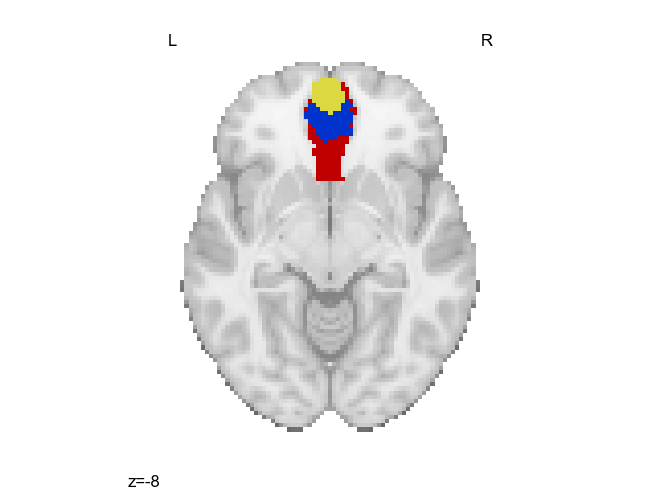

In [6]:
plot_img = nib.load(RESULTS_PATH / 'nii/K3.nii.gz')
color_map = ListedColormap(['white'] + [YELLOW, BLUE, RED])

fig, ax = plt.subplots()
ax.axis('off')
nplt.plot_stat_map(plot_img, draw_cross=False, cut_coords=[-8], display_mode='z', cmap=color_map, colorbar=False,
                   figure=fig)
fig.savefig(PLOTS_PATH / f'vol_z8_k3.svg', **PLOT_PARAMS)
fig.savefig(PLOTS_PATH / f'vol_z8_k3.png', **PLOT_PARAMS)

# Clustering Validity Metrics

To quantitatively justify the selection of the optimal number of clusters, we visualize the internal validation metrics across all tested $K$ solutions (from 2 to 6).

We construct a dual-axis line plot to display two competing metrics simultaneously:
1. **Silhouette Coefficient (Purple):** Measures cluster cohesion and separation (peaks indicate better solutions).
2. **Davies-Bouldin Index (Green):** Measures the ratio of within-cluster scatter to between-cluster separation (troughs indicate better solutions).

Smooth interpolation (`pchip_interpolate`) is applied to the curves, and the optimal values are distinctly highlighted with larger markers to visually reinforce the choice of $K$.

In [7]:
scores_dict = joblib.load(RESULTS_PATH / 'scores.list')

# key, label, direction, marker, color, darkened_color
# y_lim, y_ticks, ax_cut_pos
params = [('silhouette_scores', 'Silhouette Coefficient', max, '^', '#9B59B6', '#6c3f7f',
           (0.130, 0.155), (0.130, 0.140, 0.150,), (0, 0)),

          ('davies_bouldin_scores', 'Davies Bouldin Index', min, 'o', '#1ABC9C', '#128973',
           (1.85, 2.25), (1.9, 2.0, 2.1, 2.2), (1, 1),), ]

colors_dict = {2: [BLUE, RED],
               3: [YELLOW, BLUE, RED],
               4: [YELLOW, ORANGE, RED, BLUE],
               5: [RED, BLUE, ORANGE, YELLOW, GREEN],
               6: [YELLOW, GREEN, ORANGE, RED, GOLD, BLUE], }

NameError: name 'PLOT_PATH' is not defined

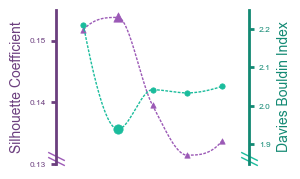

In [8]:
fig, ax1 = plt.subplots(figsize=(2.5, 2))
ax2 = ax1.twinx()
axes = [ax1, ax2]

# plot scores: lines and points
x, d = N_CLUSTER_LIST, 0.5
for i, ax in enumerate(axes):
    (key, label, direction, marker, color, darkened_color, ylim, yticks, ax_cut_pos) = params[i]
    y = scores_dict[key]

    # plot smooth line
    x_smooth = np.linspace(x[0], x[-1], 500)
    y_smooth = pchip_interpolate(x, y, x_smooth)
    sns.lineplot(x=x_smooth, y=y_smooth, color=color, ax=ax, dashes=(2, 1), linewidth=1)

    # plot points
    kwargs = dict(ax=ax, zorder=2, linewidth=0.5, facecolor=color, edgecolor=color, marker=marker)
    optimal_y = direction(y)
    optimal_x = x[y.index(optimal_y)]
    sns.scatterplot(x=x, y=y, s=15, **kwargs)
    sns.scatterplot(x=[optimal_x], y=[optimal_y], s=45, **kwargs)

    # set up axis
    ax.set_ylabel(label, color=darkened_color, fontsize=10)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, color=darkened_color, fontsize=6)
    ax.set_ylim(ylim)
    ax.tick_params(axis='y', colors=darkened_color)

    # add cut in axis
    kwargs = dict(markersize=12, linestyle="none", color=darkened_color, mec=color, mew=1, clip_on=False)
    ax.plot(ax_cut_pos, [0.02, 0.05], marker=[(-1, d), (1, -d)], transform=ax2.transAxes, **kwargs)

# plot settings
ax2.spines['left'].set_color(params[0][5])
ax2.spines['left'].set_linewidth(2)
ax1.tick_params(axis='y', width=2)

ax2.spines['right'].set_color(params[1][5])
ax2.spines['right'].set_linewidth(2)
ax2.tick_params(axis='y', width=2)

ax2.spines['bottom'].set_color('black')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.spines['bottom'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

ax2.set_xticks([])
ax2.set_xticklabels([], fontsize=12)
ax2.set_xlim(1.2, 6.8)

# save figure
fig.savefig(PLOT_PATH / 'scores.svg', **PLOT_PARAMS)
fig.savefig(PLOT_PATH / 'scores.png', **PLOT_PARAMS)

# Functional Profiles

To comprehensively illustrate the functional specialization of each $K=3$ subregion, we generate a polar radar plot based on the Neurosynth decoding results.

**Data Reordering:** Before plotting, the 15 selected cognitive terms are logically grouped and reordered into three primary domains: **Valuation/Reward**, **Social/Self**, and **Emotion/Affective**.

By plotting the correlation profiles of the three subregions on this grouped polar axis, the radar chart clearly demonstrates the functional dissociation of the VMPFC: each anatomical cluster exhibits a distinct "spike" in its corresponding cognitive domain.

In [9]:
# load plot data
plot_data = pd.read_csv(RESULTS_PATH / 'neurosynth_decode/top15_terms.csv', index_col=0)
order = ['value', 'decision making', 'reward',
         'self',  'social', 'autobiographical', 'person','theory mind',
        'emotion', 'depression','affective',   'fear',
         'choice','motivation','food', ]
plot_data = plot_data.reindex(order)
social_list = plot_data['social'].values
emotion_list = plot_data['emotion'].values
valuation_list = plot_data['valuation'].values

social_list = np.concatenate((social_list, [social_list[0]]))
emotion_list = np.concatenate((emotion_list, [emotion_list[0]]))
valuation_list = np.concatenate((valuation_list, [valuation_list[0]]))

categories = [x.title() for x in plot_data.index]
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

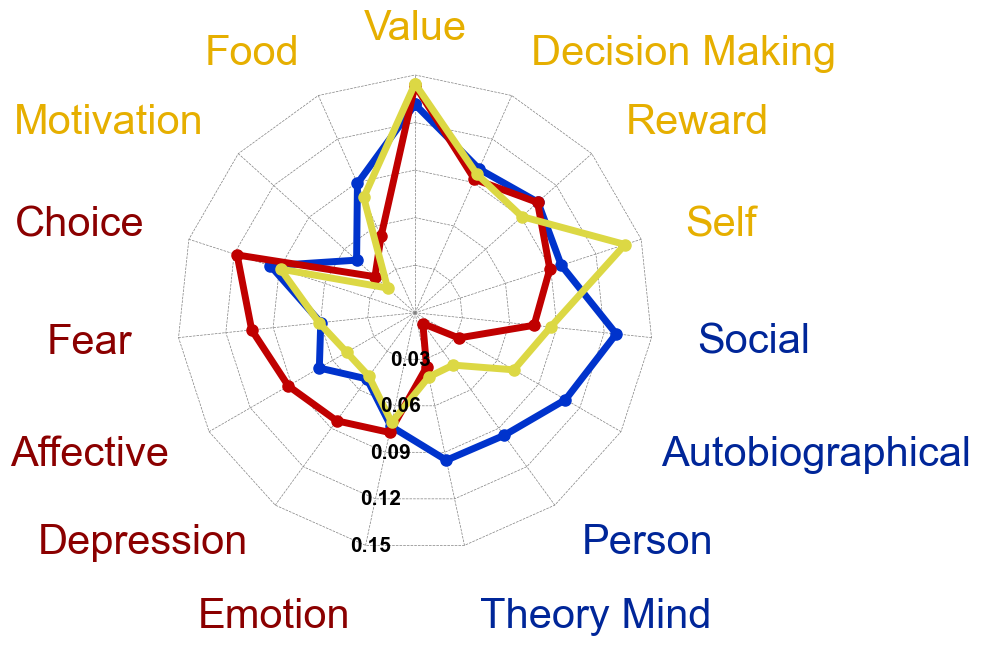

In [12]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True, ))
ax.grid(False)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.spines['polar'].set_visible(False)

# plot background grid
y_ticks = np.arange(0, 0.18, 0.03)
x_ticks = angles[:-1]
background_line_params = dict(color="grey", linewidth=0.5, linestyle="dashed", zorder=1)
for y in y_ticks:
    ax.plot(angles, [y] * len(angles), **background_line_params)
for x in x_ticks:
    ax.plot([x] * len(y_ticks), y_ticks, **background_line_params)

# plot data
line_params = dict(marker='.', linewidth=5, linestyle='solid', markersize=16, zorder=2)


ax.plot(angles, social_list, label='Social', color=BLUE, **line_params)
ax.plot(angles, emotion_list, label='Emotion', color=RED, **line_params)
ax.plot(angles, valuation_list, label='Reward', color=YELLOW, **line_params)

# set up x ticks
ax.set_xticks(x_ticks)
ax.tick_params(axis='x', pad=0)
ax.set_xticklabels(categories, fontsize=30)
alignment_list = ['center'] + ['left'] * 7 + ['right'] * 7
color_list = [DARK_YELLOW] * 4 + [DARK_BLUE] * 4 + [DARK_RED] * 5 + [DARK_YELLOW] * 2
for i, x_tick_label in enumerate(ax.get_xticklabels()):
    x_tick_label.set_horizontalalignment(alignment_list[i])
    x_tick_label.set_color(color_list[i])
    if (i == 7) or (i == 8):
        x_tick_label.set_y(-0.1)

# set up y ticks
ax.set_ylim(0, 0.17)
ax.set_yticklabels([])
annotation_params = dict(xytext=(5, 5), textcoords='offset points', ha='center', va='center',
                         fontweight='bold', fontsize=15, zorder=4, )
for y in y_ticks[1:]:
    ax.annotate(text=f'{y:.2f}', xy=(angles[8], y + 0.005), **annotation_params)

fig.savefig(PLOTS_PATH / 'radar_plot.svg', **PLOT_PARAMS)
fig.savefig(PLOTS_PATH / 'radar_plot.png', **PLOT_PARAMS)
plt.show()

ax.set_xticklabels([], fontsize=30)
fig.savefig(PLOTS_PATH / 'radar_plot_NoLabels.svg', **PLOT_PARAMS)
fig.savefig(PLOTS_PATH / 'radar_plot_NoLabels.png', **PLOT_PARAMS)